In [170]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any, Optional
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState, START
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate
import pandas as pd
from langchain_groq import ChatGroq

In [171]:
from pydantic import BaseModel

class CEODecision(BaseModel):
    next_agent: Literal[
        "planner",
        "cleaner",
        "feature_engineer",
        "model_builder",
        "evaluator",
        "visualization",
        "report_generator",
        "end",
    ]
    reason: str

In [172]:
class CleaningReport(BaseModel):
    rows_before: int
    rows_after: int

    columns: int

    missing_values_removed: int

    duplicates_removed: int

    status: str

In [173]:
class FeatureEngineeringReport(BaseModel):
    encoded_columns: list[str]
    dropped_columns: list[str]
    created_features: list[str]
    status: str

In [174]:
class EvaluationReport(BaseModel):

    rows: int

    columns: int

    numerical_columns: list[str]

    categorical_columns: list[str]

    missing_values: int

    duplicate_rows: int

    status: str

In [175]:
class ReportGeneratorReport(BaseModel):

    report_path: str

    sections: list[str]

    status: str

In [176]:
class VisualizationReport(BaseModel):

    charts_created: list[str]

    saved_files: list[str]
    
    total_charts: int

    status: str

In [177]:
class TodoItem(BaseModel):
    task: str
    owner: Literal[
        "Cleaner",
        "Feature Engineer",
        "Model Builder",
        "Evaluator",
        "Visualization",
        "Report Generator",
    ]
    status: Literal["Pending", "In Progress", "Completed"]

class PlannerOutput(BaseModel):
    todo_list: List[TodoItem]
    
class CEOState(MessagesState):
    """A state for AI DS agents."""
    
    #User request
    user_request: str
    # Dataset
    dataset_path: Optional[str]
    dataframe: pd.DataFrame | None
    
    # Planner output
    todo_list: List[TodoItem]
    ceo_decision: CEODecision
    
    #Feedback from agents
    engineered_dataframe: pd.DataFrame | None
    
    #Evaluation report
    evaluation_report: EvaluationReport | None

    cleaning_report: CleaningReport | None

    feature_engineering_report: FeatureEngineeringReport | None

    evaluation_report: EvaluationReport | None
    visualization_report: VisualizationReport | None
    
    report_generator_report: ReportGeneratorReport | None
    

In [178]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [179]:
llm=ChatGroq(model_name="llama-3.3-70b-versatile")
structured_llm = llm.with_structured_output(CEODecision)
structured_planner_llm = llm.with_structured_output(PlannerOutput)

In [180]:
# def create_ceo_chain():
#     ceo_prompt = ChatPromptTemplate.from_messages(
#         [
#             (
#                 "system",
#                 """
# You are the CEO of an AI Data Science Team.

# Responsibilities:

# 1. If no execution plan exists, delegate to the Planner.

# 2. If a plan already exists:
#    - Review the TODO list.

#    - Return "end".

# Never perform the work yourself.
# Only decide who should work next.
# """
#             ),
#             (
#                 "human",
#                 """
# User Request:
# {user_request}

# Dataset:
# {dataset_path}

# TODO List:
# {todo_list}
# """
#             )
#         ]
#     )

#     return ceo_prompt | structured_llm

In [181]:
# def create_ceo_agent(state: CEOState) -> Dict:
#     ceo_chain = create_ceo_chain()

#     response = ceo_chain.invoke(
#         {
#             "user_request": state["user_request"],
#             "dataset_path": state["dataset_path"],
#             "todo_list": state.get("todo_list", []),
#         }
#     )

#     return {
#         "ceo_decision": response,
#         "messages": [
#             AIMessage(content=f"CEO selected {response.next_agent}: {response.reason}")
#         ],
#     }

In [182]:
# def create_ceo_agent(state: CEOState):

#     todo_list = state.get("todo_list", [])

#     # No plan yet
#     if not todo_list:
#         decision = CEODecision(
#             next_agent="planner",
#             reason="No execution plan exists."
#         )

#     else:
#         # Find the first pending task
#         pending_task = next(
#             (task for task in todo_list if task.status == "Pending"),
#             None
#         )

#         # All tasks completed
#         if pending_task is None:
#             decision = CEODecision(
#                 next_agent="end",
#                 reason="All tasks have been completed."
#             )

#         # Route based on task owner
#         elif pending_task.owner == "Cleaner":
#             decision = CEODecision(
#                 next_agent="cleaner",
#                 reason=f"Routing '{pending_task.task}' to Cleaner."
#             )

#         elif pending_task.owner == "Feature Engineer":
#             decision = CEODecision(
#                 next_agent="feature_engineer",
#                 reason=f"Routing '{pending_task.task}' to Feature Engineer."
#             )

#         elif pending_task.owner == "Model Builder":
#             decision = CEODecision(
#                 next_agent="model_builder",
#                 reason=f"Routing '{pending_task.task}' to Model Builder."
#             )

#         elif pending_task.owner == "Evaluator":
#             decision = CEODecision(
#                 next_agent="evaluator",
#                 reason=f"Routing '{pending_task.task}' to Evaluator."
#             )

#         elif pending_task.owner == "Visualization":
#             decision = CEODecision(
#                 next_agent="visualization",
#                 reason=f"Routing '{pending_task.task}' to Visualization."
#             )

#         elif pending_task.owner == "Report Generator":
#             decision = CEODecision(
#                 next_agent="report_generator",
#                 reason=f"Routing '{pending_task.task}' to Report Generator."
#             )

#         else:
#             decision = CEODecision(
#                 next_agent="end",
#                 reason=f"Unknown task owner: {pending_task.owner}"
#             )

#     return {
#         "ceo_decision": decision,
#         "messages": [
#             AIMessage(content=decision.reason)
#         ]
#     }

In [183]:
OWNER_TO_AGENT = {
    "cleaner": "cleaner",
    "feature engineer": "feature_engineer",
    "model builder": "model_builder",
    "evaluator": "evaluator",
    "visualization": "visualization",
    "report generator": "report_generator",
}

In [184]:
def create_ceo_agent(state: CEOState):

    todo = state.get("todo_list")

    if not todo:
        decision = CEODecision(
            next_agent="planner",
            reason="No execution plan exists."
        )

    else:

        # Find the first pending task
        pending_task = next(
            (task for task in todo if task.status == "Pending"),
            None
        )

        # All tasks completed
        if pending_task is None:
            decision = CEODecision(
                next_agent="end",
                reason="All tasks have been completed."
            )

        else:
            owner = pending_task.owner.strip().lower()

            agent = OWNER_TO_AGENT.get(owner)

            if agent is None:
                raise ValueError(
                    f"Unknown task owner: {pending_task.owner}"
                )

            decision = CEODecision(
                next_agent=agent,
                reason=f"Routing '{pending_task.task}' to {pending_task.owner}."
            )
    print("\n=== CEO STATE ===")
    print("Todo exists:", "todo_list" in state)

    todo = state.get("todo_list")

    print("Todo type:", type(todo))
    print("Todo value:", todo)

    if todo:
        print("Length:", len(todo))
        for i, task in enumerate(todo):
            print(i, task)

    return {
        "ceo_decision": decision,
        "messages": [
            AIMessage(content=decision.reason)
        ]
    }

In [185]:
def create_planner_chain():
    """Create the Planner chain."""
    planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
    You are the Planning Agent of an AI Data Science Team.

    Your responsibilities are:

    1. Analyze the user's request.
    2. Break the work into logical tasks.
    3. Assign each task to the correct specialized agent.
    4. Set every task status to "Pending".

   Available Agents:

    1. Cleaner
    - Load dataset
    - Handle missing values
    - Remove duplicates

    2. Feature Engineer
    - Encode categorical variables
    - Scale features
    - Create new features
    
    3. Evaluator
    - Evaluate dataset quality
    - Generate summary statistics
    - Analyze feature distributions
    - Compute feature correlations
    - Identify potential outliers
    
    4. Visualization
    - Distribution plots
    - Correlation heatmap
    - Target distribution
    - Feature relationships
    
    5.Report Generator
    - Create final report
    - Summarize findings
    - Save report

    Only assign tasks to the available agents.


    Do not perform any task yourself.
    Only create the execution plan.
    """
            ),
            (
                "human",
                """
    User Request:
    {user_request}

    Dataset:
    {dataset_path}
    """
            )
        ]
    )

    return planner_prompt | structured_planner_llm

In [186]:
def create_planner_agent(state: CEOState) -> Dict:
    planner_chain= create_planner_chain()
    response = planner_chain.invoke(
        {
            "user_request": state["user_request"],
            "dataset_path": state["dataset_path"]
        }
    )
    todo_list = response.todo_list
    print("\n=== Planner Output ===")
    for task in todo_list:
        print(task.owner, "|", task.task, "|", task.status)
    return {
    "todo_list": todo_list,
    "current_agent": "Planner",
    "workflow_log": [
        f"Planner created {len(todo_list)} tasks."
    ],
    "messages": [
        AIMessage(
            content=f"Planner created {len(todo_list)} tasks."
        )
    ],
}
    
    

In [187]:
def create_cleaner_chain():

    cleaner_prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are the Cleaner Agent.

Responsibilities:

1. Inspect the dataset.
2. Suggest basic cleaning steps.
3. Never perform feature engineering.
4. Never build models.
5. Never perform EDA.

Only describe the cleaning operations.
"""
            ),
            (
                "human",
                """
User Request:
{user_request}

Dataset Summary:
{summary}
"""
            ),
        ]
    )

    return cleaner_prompt | structured_llm

In [188]:
def create_cleaner_agent(state: CEOState):

    df = pd.read_csv(state["dataset_path"])

    rows_before = len(df)

    duplicates = df.duplicated().sum()

    missing = df.isnull().sum().sum()

    df = df.drop_duplicates()

    df = df.drop_duplicates()

    numeric_columns = df.select_dtypes(include="number").columns

    for col in numeric_columns:
        df[col] = df[col].fillna(df[col].median())

    categorical_columns = df.select_dtypes(exclude="number").columns

    for col in categorical_columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    rows_after = len(df)

    report = CleaningReport(
        rows_before=rows_before,
        rows_after=rows_after,
        columns=len(df.columns),
        missing_values_removed=int(missing),
        duplicates_removed=int(duplicates),
        status="Completed",
    )
    updated_tasks = []

    for task in state["todo_list"]:
        if task.owner == "Cleaner":
            updated_tasks.append(
                TodoItem(
                    task=task.task,
                    owner=task.owner,
                    status="Completed",
                )
            )
        else:
            updated_tasks.append(task)

    return {
        "todo_list": updated_tasks,
        "dataframe": df,
        "cleaning_report": report,
        "current_agent": "Cleaner",
        "messages": [
            AIMessage(
                content="Dataset cleaned successfully."
            )
        ]
    }

In [189]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd


def create_feature_engineer_agent(state: CEOState):

    df = state["dataframe"].copy()

    encoded_columns = []

    dropped_columns = []

    created_features = []

    # Encode categorical columns
    categorical_columns = df.select_dtypes(include=["object", "str"]).columns

    for column in categorical_columns:

        encoder = LabelEncoder()

        df[column] = encoder.fit_transform(df[column].astype(str))

        encoded_columns.append(column)

    # Drop unnecessary columns
    for column in ["PassengerId"]:

        if column in df.columns:

            df.drop(columns=column, inplace=True)

            dropped_columns.append(column)

    report = FeatureEngineeringReport(
        encoded_columns=encoded_columns,
        dropped_columns=dropped_columns,
        created_features=created_features,
        status="Completed",
    )

    updated_tasks = []

    for task in state["todo_list"]:

        if task.owner == "Feature Engineer":

            updated_tasks.append(
                TodoItem(
                    task=task.task,
                    owner=task.owner,
                    status="Completed",
                )
            )

        else:

            updated_tasks.append(task)
    print("=== Feature Engineer Return ===")
    print("Keys being returned:")
    print({
        "engineered_dataframe": type(df),
        "todo_list": type(updated_tasks),
        "feature_engineering_report": type(report),
    })

    return {
        "engineered_dataframe": df,
        "feature_engineering_report": report,
        "todo_list": updated_tasks,
        "messages": [
            AIMessage(
                content="Feature engineering completed successfully."
            )
        ],
    }

In [190]:
def create_evaluator_agent(state: CEOState):
    print("State keys:", state.keys())

    print("=== Evaluator ===")
    print("State keys:", list(state.keys()))

    print("Has dataframe:", "dataframe" in state)
    print("Has engineered_dataframe:", "engineered_dataframe" in state)

    df = state.get("engineered_dataframe")

    if df is None:
        raise ValueError(
            f"engineered_dataframe missing.\nAvailable keys: {list(state.keys())}"
        )

    numerical_columns = df.select_dtypes(include="number").columns.tolist()

    categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

    report = EvaluationReport(

        rows=len(df),

        columns=df.shape[1],

        numerical_columns=numerical_columns,

        categorical_columns=categorical_columns,

        missing_values=int(df.isnull().sum().sum()),

        duplicate_rows=int(df.duplicated().sum()),

        status="Completed",
    )

    updated_tasks = []

    for task in state["todo_list"]:

        if task.owner == "Evaluator":

            updated_tasks.append(
                TodoItem(
                    task=task.task,
                    owner=task.owner,
                    status="Completed",
                )
            )

        else:

            updated_tasks.append(task)

    return {

        "evaluation_report": report,

        "todo_list": updated_tasks,

        "messages":[
            AIMessage(
                content="Dataset evaluation completed successfully."
            )
        ]
    }

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

output_dir = Path("outputs")

output_dir.mkdir(exist_ok=True)

def create_visualization_agent(state):

    df = state["engineered_dataframe"].copy()

    output_dir = Path("outputs")

    output_dir.mkdir(exist_ok=True)

    charts = []

    # Histogram

    plt.figure(figsize=(8,5))
    df.hist(figsize=(12,10))
    plt.tight_layout()

    hist_path = output_dir/"histograms.png"

    plt.savefig(hist_path)
    plt.close()

    charts.append(str(hist_path.resolve()))


    # Correlation Heatmap

    plt.figure(figsize=(8,6))

    sns.heatmap(
        df.corr(numeric_only=True),
        annot=True,
        cmap="Blues"
    )

    heatmap_path = output_dir/"correlation_heatmap.png"

    plt.savefig(heatmap_path)

    plt.close()

    charts.append(str(heatmap_path.resolve()))
    
    # Target Distribution

    plt.figure(figsize=(6,4))

    sns.countplot(
        x="Survived",
        data=df
    )

    plt.title("Target Distribution")

    target_path = output_dir/"target_distribution.png"

    plt.savefig(target_path)

    plt.close()

    charts.append(str(target_path.resolve()))
    
    # Feature Relationships

    plt.figure(figsize=(7,6))

    sns.scatterplot(
        data=df,
        x="Age",
        y="Fare",
        hue="Survived"
    )

    relationship_path = output_dir/"feature_relationships.png"

    plt.savefig(relationship_path)

    plt.close()

    charts.append(str(relationship_path.resolve()))


    report = VisualizationReport(
        charts_created=[
            "Histograms",
            "Correlation Heatmap",
            "Target Distribution",
            "Feature Relationships"
        ],
        saved_files=charts,
        total_charts=len(charts),
        status="Completed"
    )
    updated_tasks = []
    for task in state["todo_list"]:
        if task.owner == "Visualization":
            updated_tasks.append(
                TodoItem(
                    task=task.task,
                    owner=task.owner,
                    status="Completed",
                )
            )
        else:
            updated_tasks.append(task)
    

    return {
        "visualization_report": report,
        "todo_list": updated_tasks,
        "messages": [
            AIMessage(
                content=f"Visualization completed successfully. Generated {len(charts)} charts."
            )
        ]
    }

In [192]:
from pathlib import Path

def create_report_generator_agent(state):

    output_dir = Path("outputs")
    output_dir.mkdir(exist_ok=True)

    report_path = output_dir / "EDA_Report.md"

    cleaning = state["cleaning_report"]
    feature = state["feature_engineering_report"]
    evaluation = state["evaluation_report"]
    visualization = state["visualization_report"]

    report = f"""
# AI Data Science Team Report

---

## Dataset Cleaning

Rows Before: {cleaning.rows_before}

Rows After: {cleaning.rows_after}

Columns: {cleaning.columns}

Missing Values Removed: {cleaning.missing_values_removed}

Duplicate Rows Removed: {cleaning.duplicates_removed}

Status: {cleaning.status}

---

## Feature Engineering

Encoded Columns:

{", ".join(feature.encoded_columns)}

Dropped Columns:

{", ".join(feature.dropped_columns)}

Created Features:

{", ".join(feature.created_features) if feature.created_features else "None"}

Status: {feature.status}

---

## Dataset Evaluation

Rows: {evaluation.rows}

Columns: {evaluation.columns}

Missing Values: {evaluation.missing_values}

Duplicate Rows: {evaluation.duplicate_rows}

Numerical Columns:

{", ".join(evaluation.numerical_columns)}

Categorical Columns:

{", ".join(evaluation.categorical_columns) if evaluation.categorical_columns else "None"}

Status: {evaluation.status}

---

## Visualizations

Charts Generated:

{chr(10).join("- " + chart for chart in visualization.charts_created)}

Files:

{chr(10).join("- " + file for file in visualization.saved_files)}

Status: {visualization.status}

---

## Conclusion

✔ Dataset cleaned successfully.

✔ Features engineered successfully.

✔ Dataset evaluated successfully.

✔ Visualizations generated successfully.

AI Data Science Team completed the workflow successfully.
"""

    report_path.write_text(report, encoding="utf-8")

    report_info = ReportGeneratorReport(
        report_path=str(report_path.resolve()),
        sections=[
            "Cleaning",
            "Feature Engineering",
            "Evaluation",
            "Visualization",
            "Conclusion"
        ],
        status="Completed"
    )

    updated_tasks = []

    for task in state["todo_list"]:

        if task.owner == "Report Generator":

            updated_tasks.append(
                TodoItem(
                    task=task.task,
                    owner=task.owner,
                    status="Completed"
                )
            )

        else:

            updated_tasks.append(task)

    return {

        "report_generator_report": report_info,

        "todo_list": updated_tasks,

        "messages":[
            AIMessage(
                content="Final report generated successfully."
            )
        ]
    }

# Graph

In [193]:
def ceo_router(state: CEOState) -> str:
    return state["ceo_decision"].next_agent.lower().strip()

In [194]:
# builder = StateGraph(CEOState)

# builder.add_node("ceo", create_ceo_agent)
# builder.add_node("planner", create_planner_agent)
# builder.add_node("cleaner", create_cleaner_agent)
# builder.add_node("feature_engineer", create_feature_engineer_agent)
# builder.add_node("visualization", create_visualization_agent)
# builder.add_node("report_generator", create_report_agent)

# builder.add_edge(START, "ceo")

# builder.add_conditional_edges(
#     "ceo",
#     ceo_router,
#     {
#         "planner": "planner",
#         "cleaner": "cleaner",
#         "feature_engineer": "feature_engineer",
#         "visualization": "visualization",
#         "report_generator": "report_generator",
#         "end": END,
#     },
# )

# builder.add_edge("planner", "ceo")
# builder.add_edge("cleaner", "ceo")
# builder.add_edge("feature_engineer", "ceo")
# builder.add_edge("visualization", "ceo")
# builder.add_edge("report_generator", "ceo")

# graph = builder.compile()

In [195]:
builder = StateGraph(CEOState)
builder.add_node("CEO", create_ceo_agent)
builder.add_node("Planner", create_planner_agent)
builder.add_node("Cleaner", create_cleaner_agent)
builder.add_node("Feature Engineer", create_feature_engineer_agent)
builder.add_node("Evaluator", create_evaluator_agent)
builder.add_node("Visualization", create_visualization_agent)
builder.add_node("Report Generator", create_report_generator_agent)

builder.add_edge(START, "CEO")
builder.add_conditional_edges(
    "CEO",
    ceo_router,
    {
        "planner": "Planner",
        "cleaner": "Cleaner",
        "feature_engineer": "Feature Engineer",
        "evaluator": "Evaluator",
        "visualization": "Visualization",
        "report_generator": "Report Generator",
        "end": END,
    },
)
builder.add_edge("Planner", "CEO")
builder.add_edge("Cleaner", "CEO")
builder.add_edge("Feature Engineer", "CEO")
builder.add_edge("Evaluator", "CEO")
builder.add_edge("Visualization", "CEO")
builder.add_edge("Report Generator", "CEO")

graph = builder.compile()

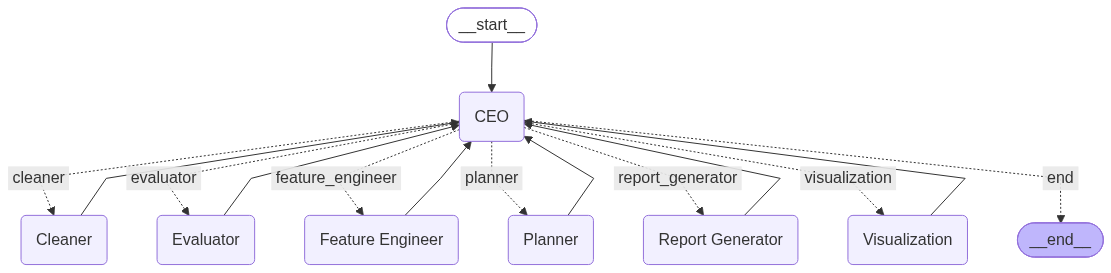

In [196]:
graph

In [197]:
state = {
    "messages": [],
    "user_request": "Perform exploratory data analysis on this dataset.",
    "dataset_path": "datasets/Titanic-Dataset.csv",
}

In [198]:
result = graph.invoke(state)


=== CEO STATE ===
Todo exists: False
Todo type: <class 'NoneType'>
Todo value: None

=== Planner Output ===
Cleaner | Load dataset | Pending
Cleaner | Handle missing values | Pending
Cleaner | Remove duplicates | Pending
Feature Engineer | Encode categorical variables | Pending
Feature Engineer | Scale features | Pending
Feature Engineer | Create new features | Pending
Evaluator | Evaluate dataset quality | Pending
Evaluator | Generate summary statistics | Pending
Evaluator | Analyze feature distributions | Pending
Evaluator | Compute feature correlations | Pending
Evaluator | Identify potential outliers | Pending
Visualization | Distribution plots | Pending
Visualization | Correlation heatmap | Pending
Visualization | Target distribution | Pending
Visualization | Feature relationships | Pending
Report Generator | Create final report | Pending
Report Generator | Summarize findings | Pending
Report Generator | Save report | Pending

=== CEO STATE ===
Todo exists: True
Todo type: <class

<Figure size 800x500 with 0 Axes>

In [199]:
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================

No execution plan exists.
================================== Ai Message ==================================

Planner created 18 tasks.
================================== Ai Message ==================================

Routing 'Load dataset' to Cleaner.
================================== Ai Message ==================================

Dataset cleaned successfully.
================================== Ai Message ==================================

Routing 'Encode categorical variables' to Feature Engineer.
================================== Ai Message ==================================

Feature engineering completed successfully.
================================== Ai Message ==================================

Routing 'Evaluate dataset quality' to Evaluator.
================================== Ai Message ==================================

Dataset evaluation completed successfully.
===============================

In [200]:
result

{'messages': [AIMessage(content='No execution plan exists.', additional_kwargs={}, response_metadata={}, id='9ccd227f-2bd3-4cfc-a5a1-3432bf633635', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Planner created 18 tasks.', additional_kwargs={}, response_metadata={}, id='a2a17cde-57ed-4c48-b643-b540ce5855d5', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="Routing 'Load dataset' to Cleaner.", additional_kwargs={}, response_metadata={}, id='e24b9e09-9180-446e-bba0-d2947efb91f8', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Dataset cleaned successfully.', additional_kwargs={}, response_metadata={}, id='af4e7336-b545-4630-a185-ba367514aeb0', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="Routing 'Encode categorical variables' to Feature Engineer.", additional_kwargs={}, response_metadata={}, id='baed7ce2-5931-4a95-8c01-153b44980326', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Feature engineering completed successfully.',

In [201]:
print(result["todo_list"])

[TodoItem(task='Load dataset', owner='Cleaner', status='Completed'), TodoItem(task='Handle missing values', owner='Cleaner', status='Completed'), TodoItem(task='Remove duplicates', owner='Cleaner', status='Completed'), TodoItem(task='Encode categorical variables', owner='Feature Engineer', status='Completed'), TodoItem(task='Scale features', owner='Feature Engineer', status='Completed'), TodoItem(task='Create new features', owner='Feature Engineer', status='Completed'), TodoItem(task='Evaluate dataset quality', owner='Evaluator', status='Completed'), TodoItem(task='Generate summary statistics', owner='Evaluator', status='Completed'), TodoItem(task='Analyze feature distributions', owner='Evaluator', status='Completed'), TodoItem(task='Compute feature correlations', owner='Evaluator', status='Completed'), TodoItem(task='Identify potential outliers', owner='Evaluator', status='Completed'), TodoItem(task='Distribution plots', owner='Visualization', status='Completed'), TodoItem(task='Corre